In [ ]:
%pip install yfinance pandas numpy pandas_ta scikit-learn matplotlib 


Defaulting to user installation because normal site-packages is not writeable
  Installing build dependencies: started
  Installing build dependencies: finished with status 'done'
  Getting requirements to build wheel: started
  Getting requirements to build wheel: finished with status 'error'
Note: you may need to restart the kernel to use updated packages.


  error: subprocess-exited-with-error
  
  × Getting requirements to build wheel did not run successfully.
  │ exit code: 1
  ╰─> [15 lines of output]
      The 'sklearn' PyPI package is deprecated, use 'scikit-learn'
      rather than 'sklearn' for pip commands.
      
      Here is how to fix this error in the main use cases:
      - use 'pip install scikit-learn' rather than 'pip install sklearn'
      - replace 'sklearn' by 'scikit-learn' in your pip requirements files
        (requirements.txt, setup.py, setup.cfg, Pipfile, etc ...)
      - if the 'sklearn' package is used by one of your dependencies,
        it would be great if you take some time to track which package uses
        'sklearn' instead of 'scikit-learn' and report it to their issue tracker
      - as a last resort, set the environment variable
        SKLEARN_ALLOW_DEPRECATED_SKLEARN_PACKAGE_INSTALL=True to avoid this error
      
      More information is available at
      https://github.com/scikit-learn/sklearn-

In [ ]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

print("libraries installed successfully!")

ImportError: Numba needs NumPy 2.2 or less. Got NumPy 2.5.

In [ ]:
data = yf.download("GC=F", interval = "1d", period="2y")

[*********************100%***********************]  1 of 1 completed


In [ ]:
data.to_csv('data')

In [ ]:

data.shape
data.isna().sum()

Price   Ticker
Close   GC=F      0
High    GC=F      0
Low     GC=F      0
Open    GC=F      0
Volume  GC=F      0
dtype: int64

In [ ]:
data.head(2)


Price,Close,High,Low,Open,Volume
Ticker,GC=F,GC=F,GC=F,GC=F,GC=F
Date,,,,,
2024-07-19,2395.5,2419.199951,2395.5,2418.800049,15
2024-07-22,2392.0,2402.100098,2392.0,2402.100098,18


In [ ]:
data.info()

<class 'pandas.DataFrame'>
DatetimeIndex: 503 entries, 2024-07-19 to 2026-07-19
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   (Close, GC=F)   503 non-null    float64
 1   (High, GC=F)    503 non-null    float64
 2   (Low, GC=F)     503 non-null    float64
 3   (Open, GC=F)    503 non-null    float64
 4   (Volume, GC=F)  503 non-null    int64  
dtypes: float64(4), int64(1)
memory usage: 23.6 KB


In [ ]:
data.columns = ['Close', 'High', 'Low', 'Open', 'Volume']


In [ ]:
data.info()

<class 'pandas.DataFrame'>
DatetimeIndex: 503 entries, 2024-07-19 to 2026-07-19
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Close   503 non-null    float64
 1   High    503 non-null    float64
 2   Low     503 non-null    float64
 3   Open    503 non-null    float64
 4   Volume  503 non-null    int64  
dtypes: float64(4), int64(1)
memory usage: 23.6 KB


To handle look ahead Leakage 

In [ ]:
data["tomorrow_close"] = data["Close"].shift(-1)
data['direction'] = np.where(data["tomorrow_close"] > data["Close"], 1, 0)
data.dropna(subset=["tomorrow_close"], inplace = True)
data["direction"].value_counts()






direction
1    287
0    215
Name: count, dtype: int64

Defaulting to user installation because normal site-packages is not writeable
   ---------------------------------------- 0.0/9.3 MB ? eta -:--:--
   ---------------------------------------- 0.0/9.3 MB ? eta -:--:--
   ---------------------------------------- 0.0/9.3 MB ? eta -:--:--
   ---------------------------------------- 0.0/9.3 MB ? eta -:--:--
   ---------------------------------------- 0.0/9.3 MB ? eta -:--:--
   ---------------------------------------- 0.0/9.3 MB ? eta -:--:--
   ---------------------------------------- 0.0/9.3 MB ? eta -:--:--
   - -------------------------------------- 0.3/9.3 MB ? eta -:--:--
   - -------------------------------------- 0.3/9.3 MB ? eta -:--:--
   - -------------------------------------- 0.3/9.3 MB ? eta -:--:--
   - -------------------------------------- 0.3/9.3 MB ? eta -:--:--
   - -------------------------------------- 0.3/9.3 MB ? eta -:--:--
   - -------------------------------------- 0.3/9.3 MB ? eta -:--:--
   -- -------------------

<Axes: title={'center': 'Gold Price'}, xlabel='Date'>

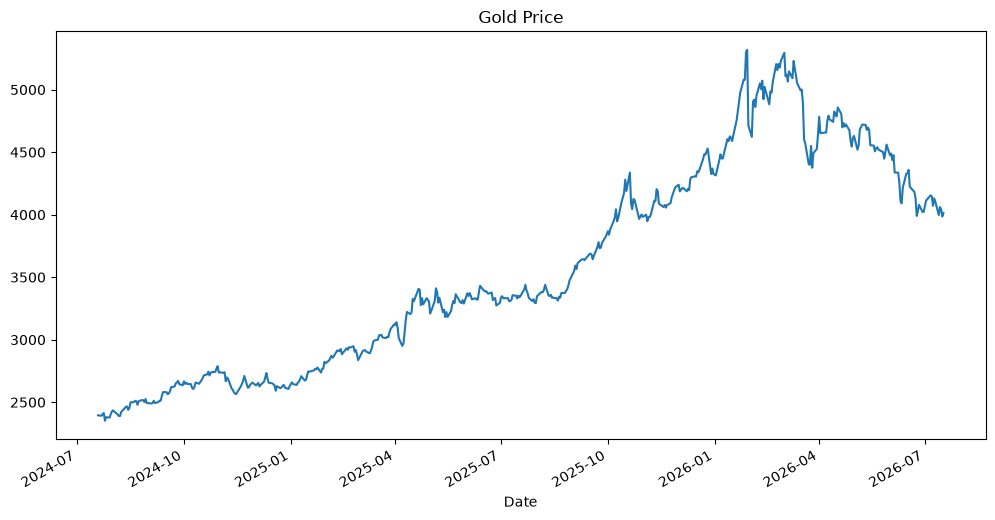

In [ ]:
#plotting a graph to check the movement and trend of gold ove the last two years 

data['Close'].plot(title = "Gold Price", figsize = (12,6))

In [ ]:
#the quantitative mathematics

# 1. Previous Candle Return
data['pcr'] = data['Close'].pct_change(1)

# 2. High-Low Range %
data['hlr'] = (data['High'] - data['Low']) / data['Close']

# 3. SMA Difference (5-period minus 20-period)
data['sma_diff'] = data['Close'].rolling(window=5).mean() - data['Close'].rolling(window=20).mean()

### 4. RSI (14-period)
# calculating day-to-day price differences
delta = data['Close'].diff()

# Isolating daily gains and losses
gain = delta.clip(lower=0)
loss = -delta.clip(upper=0)

#  the 14-period exponential moving averages of gains and losses
avg_gain = gain.ewm(com=13, adjust=False).mean()
avg_loss = loss.ewm(com=13, adjust=False).mean()

#  Relative Strength (RS) and scale to the 0-100 RSI boundaries
rs = avg_gain / avg_loss
data['rsi'] = 100 - (100 / (1 + rs))





####5. Average True Range
#  the three absolute metrics that make up the "True Range"
high_low = data['High'] - data['Low']
high_close_prev = (data['High'] - data['Close'].shift(1)).abs()
low_close_prev = (data['Low'] - data['Close'].shift(1)).abs()

# Stacing 'em horizontally and findinf the maximum true struggle per day
true_range = pd.concat([high_low, high_close_prev, low_close_prev], axis=1).max(axis=1)

# Averaging d True Range over a 14-day rolling window
data['atr'] = true_range.rolling(window=14).mean()




In [ ]:
data.shape

(502, 14)

In [ ]:
#my features
#where 
#pcr = previous candle returns
#atr = average true range
#sma_diff = sma difference(5-day_period - 20-day_period)
#hlr = high low range
#rsi = relative strenght index

X = data[["pcr", "atr", "sma_diff", "hlr", "rsi"]]


#my target
y = data["direction"]

In [ ]:

data.dropna(inplace = True)

data.columns

Index(['Close', 'High', 'Low', 'Open', 'Volume', 'direction', 'sma_diff',
       'rsi', 'atr', 'pcr', 'hlr'],
      dtype='str')

In [ ]:
data.head(50)

,Close,High,Low,Open,Volume,direction,sma_diff,rsi,atr,pcr,hlr
Date,,,,,,,,,,,
2024-08-15,2453.100098,2467.699951,2431.199951,2451.800049,285,1,37.539990,57.050839,34.707188,0.005616,0.014879
2024-08-16,2498.600098,2508.000000,2451.399902,2453.500000,197,1,45.684985,65.571845,38.557199,0.018548,0.022653
2024-08-19,2501.800049,2508.500000,2487.199951,2508.500000,88,1,48.075012,66.081516,37.542916,0.001281,0.008514
2024-08-20,2511.300049,2527.300049,2500.699951,2503.500000,187,0,51.660034,67.614343,36.242920,0.003797,0.010592
2024-08-21,2508.399902,2515.399902,2503.899902,2511.000000,96,0,60.705042,66.624488,35.021484,-0.001155,0.004585
2024-08-22,2478.899902,2504.100098,2471.100098,2504.100098,210,1,59.515002,57.416654,33.328613,-0.011760,0.013312
2024-08-23,2508.399902,2508.399902,2486.500000,2486.500000,94,1,55.054968,62.933489,29.550031,0.011900,0.008731
2024-08-26,2517.699951,2523.100098,2509.100098,2509.899902,290,0,51.214954,64.495146,27.614328,0.003708,0.005561
2024-08-27,2516.000000,2523.100098,2506.899902,2515.199951,100,0,46.604944,63.964653,27.592913,-0.000675,0.006439


In [ ]:
#spliting the index to know where my 80% lies at since i cannot
#perform a train-test-split on time-series data

split_idx = int(len(data) * 0.80)

In [ ]:
# Slicing the features (X)
X_train = X.iloc[:split_idx]
X_test = X.iloc[split_idx:]

# Slicing the target (y)
y_train = y.iloc[:split_idx]
y_test = y.iloc[split_idx:]


In [68]:
# Verify dimensions
print(X_train.shape, X_test.shape)
print(y_train.shape, y_test.shape)


(401, 5) (101, 5)
(401,) (101,)


In [69]:
data.head

<bound method NDFrame.head of                   Close         High          Low         Open  Volume  \
Date                                                                     
2024-08-15  2453.100098  2467.699951  2431.199951  2451.800049     285   
2024-08-16  2498.600098  2508.000000  2451.399902  2453.500000     197   
2024-08-19  2501.800049  2508.500000  2487.199951  2508.500000      88   
2024-08-20  2511.300049  2527.300049  2500.699951  2503.500000     187   
2024-08-21  2508.399902  2515.399902  2503.899902  2511.000000      96   
...                 ...          ...          ...          ...     ...   
2026-07-13  3997.000000  4081.000000  3985.899902  4081.000000     679   
2026-07-14  4061.100098  4091.199951  3986.500000  3995.699951    1281   
2026-07-15  4044.000000  4070.100098  4019.399902  4049.100098     374   
2026-07-16  3985.600098  4030.500000  3972.600098  4030.500000     812   
2026-07-17  4012.699951  4017.199951  3964.199951  3975.500000     812   

       

In [71]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(n_estimators=100, random_state=42)


In [72]:

model.fit(X_train, y_train)


,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstr

In [ ]:
#prediction and prediction proabilities

